### Filter out data such that it has all 3 positions

In [1]:
import pandas as pd

In [2]:
normalized_counts = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/data/GTeX_experimental_data/OL41_42_20221220_K562_normalized_counts.out", sep=r"\s+", header=None)
normalized_counts.columns = ["seq_id", "plasmid_r1", "plasmid_r2", "plasmid_r3", "plasmid_r4","plasmid_r5", "k562_r1", "k562_r2","k562_r3","k562_r4","k562_r5","k562_r6"]

In [3]:
normalized_counts['base_id'] = normalized_counts['seq_id'].str.extract(r'(^[^:]+:[^:]+:[^:]+:[^:]+:[^:]+)')

# Extract strand (wC/wR/wL)
normalized_counts['strand'] = normalized_counts['seq_id'].str.extract(r'(:w[CRL])$')

# Count unique strands per base_id
strand_counts = normalized_counts.groupby('base_id')['strand'].nunique()

# Filter to base_ids that have all 3 strand types
valid_base_ids = strand_counts[strand_counts == 3].index

# Filter original DataFrame
filtered_normalized_counts = normalized_counts[normalized_counts['base_id'].isin(valid_base_ids)].drop(columns=['base_id', 'strand'])


In [4]:
normalized_counts["base_id"]

0          (1:1009223:C:T:A
1          (1:1009223:C:T:R
2          (1:1009234:T:C:A
3          (1:1009234:T:C:R
4         (1:10490539:G:C:A
                ...        
470790     X:99996102:A:G:R
470791     X:99998829:C:T:A
470792     X:99998829:C:T:R
470793     X:99999349:G:A:A
470794     X:99999349:G:A:R
Name: base_id, Length: 470795, dtype: object

In [5]:
filtered_normalized_counts

,seq_id,plasmid_r1,plasmid_r2,plasmid_r3,plasmid_r4,plasmid_r5,k562_r1,k562_r2,k562_r3,k562_r4,k562_r5,k562_r6
64156,10:35356774:A:G:A:wC,639.489215,581.733485,698.255434,764.010394,682.295625,4907.138349,3487.939688,2623.750170,3490.092610,3854.435635,3440.346915
64157,10:35356774:A:G:A:wL,1150.659871,1134.984470,1028.928719,1062.272710,1195.362800,10291.525824,8391.590845,5791.879997,8933.684156,8872.252757,7422.358108
64158,10:35356774:A:G:A:wR,319.043413,340.926894,357.790001,408.389940,261.915411,378.507928,371.818727,422.265143,510.708944,340.788517,527.819823
64159,10:35356774:A:G:R:wC,735.552837,852.748788,674.151686,724.242085,516.057077,3295.861519,2182.684827,1637.703999,2388.271564,2262.970051,2640.829674
64160,10:35356774:A:G:R:wL,498.549158,534.262651,515.970844,529.224417,472.404508,2212.700493,1882.429537,1634.280228,1882.029462,1873.497460,1531.542766
...,...,...,...,...,...,...,...,...,...,...,...,...
446469,9:131038575:G:C:A:wL,409.497480,365.093864,353.270548,370.151182,368.355920,4917.610900,5266.135523,5077.453026,3979.956292,4653.525950,4137.761305
446470,9:131038575:G:C:A:wR,527.999319,457.446212,492.620338,510.105038,525.624763,54164.035607,74992.259009,63796.274252,52144.425472,54519.447597,54252.955626
446471,9:131038575:G:C:R:wC,360.413878,296.908485,306.569538,348.737477,293.010391,17367.978383,19566.377096,18069.524333,17370.059894,16893.373604,14171.529621
446472,9:131038575:G:C:R:wL,362.517461,347.831742,373.608085,464.983303,395.863018,2854.518284,3624.843654,3342.742170,3323.330506,3375.988703,2632.176890


### Now make sure both alleles present

In [6]:
df = filtered_normalized_counts.copy()

df[['chr', 'pos', 'ref', 'alt', 'allele', 'strand']] = df['seq_id'].str.extract(
    r'([^:]+):([^:]+):([^:]+):([^:]+):([^:]+):(w[C|L|R])'
)

df['base_id'] = df[['chr', 'pos', 'ref', 'alt', 'strand']].agg(':'.join, axis=1)

allele_counts = df.groupby(['base_id', 'allele']).size().unstack(fill_value=0)

valid_base_ids = allele_counts[(allele_counts['A'] > 0) & (allele_counts['R'] > 0)].index

df_filtered = df[df['base_id'].isin(valid_base_ids)]

df_filtered = df_filtered.drop(columns=['chr', 'pos', 'ref', 'alt', 'allele', 'strand', 'base_id'])

In [7]:
df_filtered

,seq_id,plasmid_r1,plasmid_r2,plasmid_r3,plasmid_r4,plasmid_r5,k562_r1,k562_r2,k562_r3,k562_r4,k562_r5,k562_r6
64156,10:35356774:A:G:A:wC,639.489215,581.733485,698.255434,764.010394,682.295625,4907.138349,3487.939688,2623.750170,3490.092610,3854.435635,3440.346915
64157,10:35356774:A:G:A:wL,1150.659871,1134.984470,1028.928719,1062.272710,1195.362800,10291.525824,8391.590845,5791.879997,8933.684156,8872.252757,7422.358108
64158,10:35356774:A:G:A:wR,319.043413,340.926894,357.790001,408.389940,261.915411,378.507928,371.818727,422.265143,510.708944,340.788517,527.819823
64159,10:35356774:A:G:R:wC,735.552837,852.748788,674.151686,724.242085,516.057077,3295.861519,2182.684827,1637.703999,2388.271564,2262.970051,2640.829674
64160,10:35356774:A:G:R:wL,498.549158,534.262651,515.970844,529.224417,472.404508,2212.700493,1882.429537,1634.280228,1882.029462,1873.497460,1531.542766
...,...,...,...,...,...,...,...,...,...,...,...,...
446469,9:131038575:G:C:A:wL,409.497480,365.093864,353.270548,370.151182,368.355920,4917.610900,5266.135523,5077.453026,3979.956292,4653.525950,4137.761305
446470,9:131038575:G:C:A:wR,527.999319,457.446212,492.620338,510.105038,525.624763,54164.035607,74992.259009,63796.274252,52144.425472,54519.447597,54252.955626
446471,9:131038575:G:C:R:wC,360.413878,296.908485,306.569538,348.737477,293.010391,17367.978383,19566.377096,18069.524333,17370.059894,16893.373604,14171.529621
446472,9:131038575:G:C:R:wL,362.517461,347.831742,373.608085,464.983303,395.863018,2854.518284,3624.843654,3342.742170,3323.330506,3375.988703,2632.176890


### Perform FDR and filter out for < 10%

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Define replicate columns
plasmid_cols = [f'plasmid_r{i}' for i in range(1, 6)]
k562_cols = [f'k562_r{i}' for i in range(1, 6)]  # drop k562_r6

# Extract window and strand
df['window_id'] = df['seq_id'].str.extract(r'^(\d+:\d+)')
df['strand'] = df['seq_id'].str.extract(r'(w[CRL])$')

df['allele_type'] = df['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')

# Make group key
df['window_strand'] = df['window_id'] + ':' + df['strand']

# Initialize results
results = []

# Group by window + strand
for group_id, group in df.groupby('window_strand'):
    ref = group[group['allele_type'] == 'ref']
    alt = group[group['allele_type'] == 'alt']
    
    # Match by window_id
    merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
    
    for _, row in merged.iterrows():
        try:
            plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols]].values.astype(float)
            k562_ref = row[[f'{col}_ref' for col in k562_cols]].values.astype(float)
            plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols]].values.astype(float)
            k562_alt = row[[f'{col}_alt' for col in k562_cols]].values.astype(float)

            log2_ref = np.log2((k562_ref+1 )/(plasmid_ref+1))
            log2_alt = np.log2((k562_alt+1) / (plasmid_alt+1))

            stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)

            results.append({
                'window_strand': group_id,
                'seq_id_ref': row['seq_id_ref'],
                'seq_id_alt': row['seq_id_alt'],
                'log2_fc_ref_mean': log2_ref.mean(),
                'log2_fc_alt_mean': log2_alt.mean(),
                'pval': pval
            })
        except:
            continue

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction within each window+strand group
results_df['fdr'] = results_df.groupby('window_strand')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)


In [9]:
results_df

,window_strand,seq_id_ref,seq_id_alt,log2_fc_ref_mean,log2_fc_alt_mean,pval,fdr
0,10:35356774:wC,10:35356774:A:G:R:wC,10:35356774:A:G:A:wC,1.729376,2.422908,0.026580,0.026580
1,10:35356774:wL,10:35356774:A:G:R:wL,10:35356774:A:G:A:wL,1.887585,2.899687,0.000154,0.000154
2,10:35356774:wR,10:35356774:A:G:R:wR,10:35356774:A:G:A:wR,0.024113,0.261885,0.090236,0.090236
3,12:112378909:wC,12:112378909:C:T:R:wC,12:112378909:C:T:A:wC,2.752861,2.403607,0.081136,0.081136
4,12:112378909:wL,12:112378909:C:T:R:wL,12:112378909:C:T:A:wL,2.655197,2.400354,0.308720,0.308720
...,...,...,...,...,...,...,...
133,9:123634040:wL,9:123634040:G:A:R:wL,9:123634040:G:A:A:wL,4.440214,3.810892,0.041542,0.041542
134,9:123634040:wR,9:123634040:G:A:R:wR,9:123634040:G:A:A:wR,0.867017,1.069783,0.302301,0.302301
135,9:131038575:wC,9:131038575:G:C:R:wC,9:131038575:G:C:A:wC,5.795908,6.389818,0.001326,0.001326
136,9:131038575:wL,9:131038575:G:C:R:wL,9:131038575:G:C:A:wL,3.086623,3.669918,0.001417,0.001417


In [10]:
results_df["base_id"] = results_df["window_strand"].str.extract(r"^([^:]+:[^:]+)")
filtered_results = results_df.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())

In [11]:
filtered_results

,window_strand,seq_id_ref,seq_id_alt,log2_fc_ref_mean,log2_fc_alt_mean,pval,fdr,base_id
0,10:35356774:wC,10:35356774:A:G:R:wC,10:35356774:A:G:A:wC,1.729376,2.422908,0.026580,0.026580,10:35356774
1,10:35356774:wL,10:35356774:A:G:R:wL,10:35356774:A:G:A:wL,1.887585,2.899687,0.000154,0.000154,10:35356774
2,10:35356774:wR,10:35356774:A:G:R:wR,10:35356774:A:G:A:wR,0.024113,0.261885,0.090236,0.090236,10:35356774
3,12:112378909:wC,12:112378909:C:T:R:wC,12:112378909:C:T:A:wC,2.752861,2.403607,0.081136,0.081136,12:112378909
4,12:112378909:wL,12:112378909:C:T:R:wL,12:112378909:C:T:A:wL,2.655197,2.400354,0.308720,0.308720,12:112378909
...,...,...,...,...,...,...,...,...
133,9:123634040:wL,9:123634040:G:A:R:wL,9:123634040:G:A:A:wL,4.440214,3.810892,0.041542,0.041542,9:123634040
134,9:123634040:wR,9:123634040:G:A:R:wR,9:123634040:G:A:A:wR,0.867017,1.069783,0.302301,0.302301,9:123634040
135,9:131038575:wC,9:131038575:G:C:R:wC,9:131038575:G:C:A:wC,5.795908,6.389818,0.001326,0.001326,9:131038575
136,9:131038575:wL,9:131038575:G:C:R:wL,9:131038575:G:C:A:wL,3.086623,3.669918,0.001417,0.001417,9:131038575


### Calculate variant effect

In [12]:
filtered_results["variant_effects"] = filtered_results["log2_fc_ref_mean"] - filtered_results["log2_fc_alt_mean"]

In [13]:
filtered_results['window_code'] = filtered_results['window_strand'].str.extract(r'(w[CLR])$')

pivot_filtered_results = filtered_results.pivot(index='base_id', columns='window_code', values='variant_effects')

pivot_filtered_results = pivot_filtered_results.rename(columns={
    'wL': 'left',
    'wR': 'right',
    'wC': 'centre'
}).reset_index()

pivot_filtered_results = pivot_filtered_results.dropna()

In [14]:
pivot_filtered_results

window_code,base_id,centre,left,right
0,10:35356774,-0.693531,-1.012101,-0.237772
1,12:112378909,0.349255,0.254843,-0.149317
2,12:54955169,1.740341,1.432356,1.320549
3,13:43597706,1.959047,2.011857,2.093779
4,15:44081143,1.764616,0.160185,2.246451
5,15:52796861,0.141461,-0.160049,-0.442300
6,15:65059651,-0.809087,-0.731372,-1.260198
7,15:82258451,0.999442,1.296703,-0.059475
8,16:1586255,-1.596110,-2.060755,-1.076794
9,17:43685021,0.695492,0.507835,-0.353550


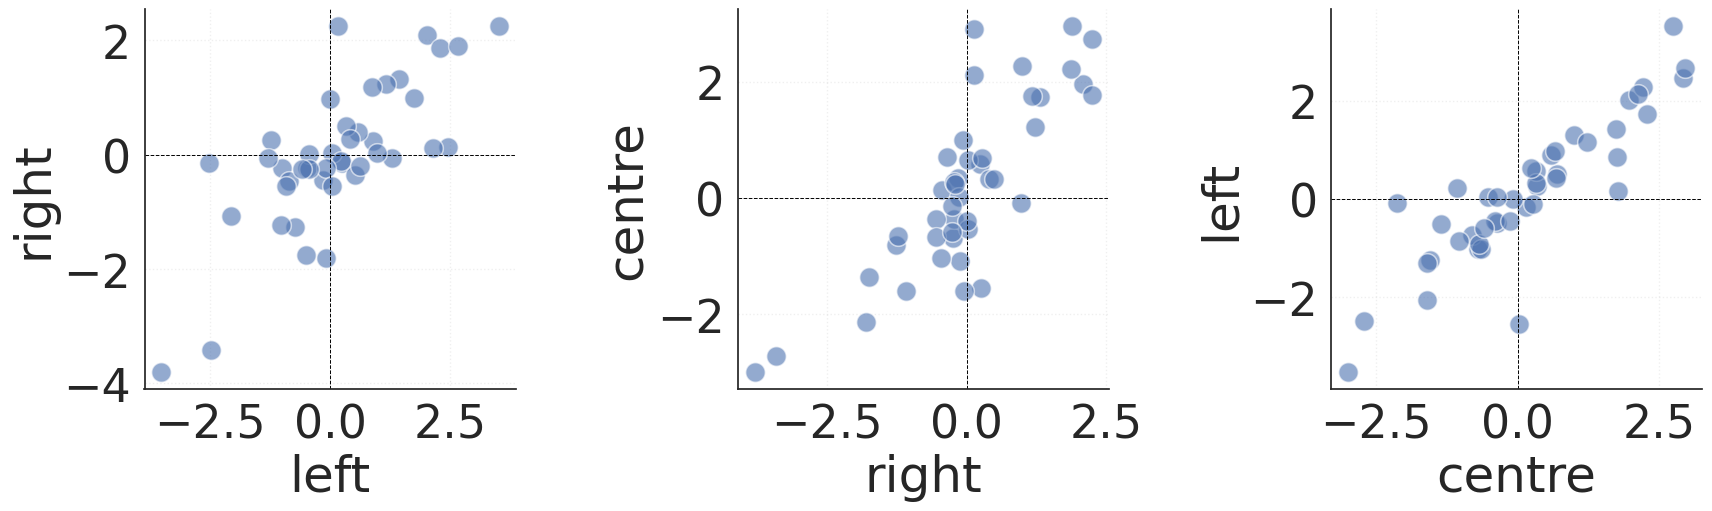

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set Seaborn style
sns.set(style="white", font_scale=3)

def plot_scatter_with_r2(ax, df, x_col, y_col):
    valid_df = df[[x_col, y_col]].dropna()
    r, _ = pearsonr(valid_df[x_col], valid_df[y_col])
    r2 = r**2
    n_points = len(valid_df)-1

    # Scatterplot
    sns.scatterplot(
        x=valid_df[x_col], y=valid_df[y_col], ax=ax,
        color="#4C72B0", edgecolor="white", s=200, alpha=0.6
    )

    # Reference lines
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.7)

    # Aesthetic tweaks
    ax.grid(True, linestyle=':', alpha=0.3)
    sns.despine(ax=ax)

# Set up figure
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot each pair
plot_scatter_with_r2(axs[0], pivot_filtered_results, 'left', 'right')
plot_scatter_with_r2(axs[1], pivot_filtered_results, 'right', 'centre')
plot_scatter_with_r2(axs[2], pivot_filtered_results, 'centre', 'left')

plt.tight_layout()
plt.savefig(f"/scratch/st-cdeboer-1/sambina/position_mpra/outputs/GTeX_experiment/corr.svg", format="svg")
plt.show()


In [16]:
print(pivot_filtered_results)
pivot_filtered_results.to_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/GTeX_experiment/42_variants.csv")

window_code       base_id    centre      left     right
0             10:35356774 -0.693531 -1.012101 -0.237772
1            12:112378909  0.349255  0.254843 -0.149317
2             12:54955169  1.740341  1.432356  1.320549
3             13:43597706  1.959047  2.011857  2.093779
4             15:44081143  1.764616  0.160185  2.246451
5             15:52796861  0.141461 -0.160049 -0.442300
6             15:65059651 -0.809087 -0.731372 -1.260198
7             15:82258451  0.999442  1.296703 -0.059475
8              16:1586255 -1.596110 -2.060755 -1.076794
9             17:43685021  0.695492  0.507835 -0.353550
10            17:43812218  2.275134  1.737231  0.993269
11            17:43838710 -0.359129 -0.491042 -0.229417
12            17:43950394 -2.128374 -0.089961 -1.799166
13            17:44139190  2.911350  2.451373  0.129620
14            17:44291820 -0.531083  0.043914  0.027971
15            17:44295052 -1.077652  0.220052 -0.112437
16            17:46983171 -1.542875 -1.241508  0

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def create_heatmap(df, title, output_file):
    plt.figure(figsize=(12, 10), dpi=300)
    pearson_corr = df.corr("pearson")
    r_squared_matrix = pearson_corr**2
    mask = np.triu(np.ones_like(r_squared_matrix, dtype=bool))

    # Remove rows and columns that are fully masked
    unmasked_rows = ~np.all(mask, axis=1)
    unmasked_cols = ~np.all(mask, axis=0)
    trimmed_matrix = r_squared_matrix.loc[unmasked_rows, unmasked_cols]
    trimmed_mask = mask[unmasked_rows, :][:, unmasked_cols]

    colors = ["#053061", "#2166ac", "#4393c3", "#92c5de", "#d1e5f0", 
              "#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"]
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=100)
    
    ax = sns.heatmap(
        trimmed_matrix, 
        annot=True, 
        mask=trimmed_mask, 
        cmap=cmap, 
        vmin=0, 
        vmax=1,
        square=True, 
        linewidths=0.5, 
        cbar_kws={"label": "Pearson R²\n(Variance Explained)", "shrink": 0.8},
        annot_kws={"size": 12, "weight": "bold"},
        fmt='.2f'  
    )
    
    ax.figure.axes[-1].yaxis.label.set_size(12)  
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    plt.title(title, fontsize=18, fontweight='bold', pad=25)
    plt.tight_layout()
    plt.savefig(output_file, format="svg")
    plt.close()

In [18]:
heatmap_df = pivot_filtered_results[[
    "left",
    "centre",
    "right"
]].dropna()

create_heatmap(
    df=heatmap_df,
    title=f"K562 GTEx variants (n={len(heatmap_df)-1}) variants",
    output_file="/scratch/st-cdeboer-1/sambina/position_mpra/outputs/GTeX_experiment/heatmap.svg"
)

### Now doing interreplicate correlation

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, pearsonr
from statsmodels.stats.multitest import multipletests
import random


r_list = []

for _ in range(500):
    
    plasmid_indices = list(range(1, 6))
    k562_indices = list(range(1, 6))
    random.shuffle(plasmid_indices)
    random.shuffle(k562_indices)

    # Randomly split into two sets
    plasmid_cols_rep1 = [f'plasmid_r{i}' for i in plasmid_indices[:3]]
    plasmid_cols_rep2 = [f'plasmid_r{i}' for i in plasmid_indices[3:]]

    k562_cols_rep1 = [f'k562_r{i}' for i in k562_indices[:3]]
    k562_cols_rep2 = [f'k562_r{i}' for i in k562_indices[3:]]

    # Make a copy of df if you're modifying in-place
    df_copy = df.copy()

    # Extract window and strand
    df_copy['window_id'] = df_copy['seq_id'].str.extract(r'^(\d+:\d+)')
    df_copy['strand'] = df_copy['seq_id'].str.extract(r'(w[CRL])$')
    df_copy['allele_type'] = df_copy['seq_id'].apply(lambda x: 'ref' if ':R:' in x else 'alt')
    df_copy['window_strand'] = df_copy['window_id'] + ':' + df_copy['strand']

    # ========== Replicate Set 1 ==========
    results = []
    for group_id, group in df_copy.groupby('window_strand'):
        ref = group[group['allele_type'] == 'ref']
        alt = group[group['allele_type'] == 'alt']
        merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
        for _, row in merged.iterrows():
            try:
                plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep1]].values.astype(float).flatten()
                k562_ref = row[[f'{col}_ref' for col in k562_cols_rep1]].values.astype(float).flatten()
                plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep1]].values.astype(float).flatten()
                k562_alt = row[[f'{col}_alt' for col in k562_cols_rep1]].values.astype(float).flatten()
                log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
                log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
                stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
                results.append({
                    'window_strand': group_id,
                    'seq_id_ref': row['seq_id_ref'],
                    'seq_id_alt': row['seq_id_alt'],
                    'log2_fc_ref_mean': log2_ref.mean(),
                    'log2_fc_alt_mean': log2_alt.mean(),
                    'pval': pval
                })
            except:
                continue
    results_df_rep1 = pd.DataFrame(results)
    results_df_rep1['fdr'] = results_df_rep1.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
    results_df_rep1['base_id'] = results_df_rep1['window_strand'].str.extract(r"^([^:]+:[^:]+)")
    filtered_results_rep1 = results_df_rep1.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
    filtered_results_rep1["variant_effects"] = filtered_results_rep1["log2_fc_ref_mean"] - filtered_results_rep1["log2_fc_alt_mean"]

    # ========== Replicate Set 2 ==========
    results = []
    for group_id, group in df_copy.groupby('window_strand'):
        ref = group[group['allele_type'] == 'ref']
        alt = group[group['allele_type'] == 'alt']
        merged = pd.merge(ref, alt, on='window_id', suffixes=('_ref', '_alt'))
        for _, row in merged.iterrows():
            try:
                plasmid_ref = row[[f'{col}_ref' for col in plasmid_cols_rep2]].values.astype(float).flatten()
                k562_ref = row[[f'{col}_ref' for col in k562_cols_rep2]].values.astype(float).flatten()
                plasmid_alt = row[[f'{col}_alt' for col in plasmid_cols_rep2]].values.astype(float).flatten()
                k562_alt = row[[f'{col}_alt' for col in k562_cols_rep2]].values.astype(float).flatten()
                log2_ref = np.log2((k562_ref + 1)/(plasmid_ref + 1))
                log2_alt = np.log2((k562_alt + 1)/(plasmid_alt + 1))
                stat, pval = ttest_ind(log2_ref, log2_alt, equal_var=False)
                results.append({
                    'window_strand': group_id,
                    'seq_id_ref': row['seq_id_ref'],
                    'seq_id_alt': row['seq_id_alt'],
                    'log2_fc_ref_mean': log2_ref.mean(),
                    'log2_fc_alt_mean': log2_alt.mean(),
                    'pval': pval
                })
            except:
                continue
    results_df_rep2 = pd.DataFrame(results)
    results_df_rep2['fdr'] = results_df_rep2.groupby('window_strand')['pval'].transform(lambda x: multipletests(x, method='fdr_bh')[1])
    results_df_rep2['base_id'] = results_df_rep2['window_strand'].str.extract(r"^([^:]+:[^:]+)")
    filtered_results_rep2 = results_df_rep2.groupby("base_id").filter(lambda group: (group["fdr"] < 0.1).any())
    filtered_results_rep2["variant_effects"] = filtered_results_rep2["log2_fc_ref_mean"] - filtered_results_rep2["log2_fc_alt_mean"]

    # ========== Merge and compute R² ==========
    merged_results = pd.merge(
        filtered_results_rep1,
        filtered_results_rep2,
        on='window_strand',
        suffixes=('_rep1', '_rep2')
    )

    x = merged_results["variant_effects_rep1"]
    y = merged_results["variant_effects_rep2"]

    mask = x.notna() & y.notna() & x.apply(np.isfinite) & y.apply(np.isfinite)
    x = x[mask]
    y = y[mask]

    if len(x) > 0:
        r, _ = pearsonr(x, y)
        r_squared = r**2
        r_list.append(r_squared)

# Done
print("R² values from 10 runs:", r_list)


R² values from 10 runs: [0.9823743359939141, 0.9586643653530957, 0.9793580139652328, 0.9667211143050303, 0.9577671091647041, 0.9637518377362797, 0.9579151085792299, 0.9668993189436444, 0.9721617660232799, 0.9585534983314177, 0.9778714370701146, 0.9666538227533713, 0.9693551103254984, 0.9683147800882409, 0.9544727111245092, 0.9650332354099851, 0.9812273823818884, 0.9590077482246576, 0.988394419366955, 0.9780675530904147, 0.9780675530904152, 0.9812273823818884, 0.9773916901078796, 0.9714455096272993, 0.9637518377362797, 0.9698020259346642, 0.9524642569929551, 0.9638981443655918, 0.9721497028575755, 0.9653948032278188, 0.968577876999625, 0.9870021807488193, 0.9768801415222951, 0.9658006800336094, 0.9714230324360227, 0.9718472673821046, 0.9748666104746069, 0.9585534983314177, 0.988394419366955, 0.9583487528454016, 0.9799480320830565, 0.9663235864452084, 0.9628271908247401, 0.9583487528454016, 0.9707626892691466, 0.9654771578818753, 0.9467903500837298, 0.977064249843919, 0.9849307666159001,

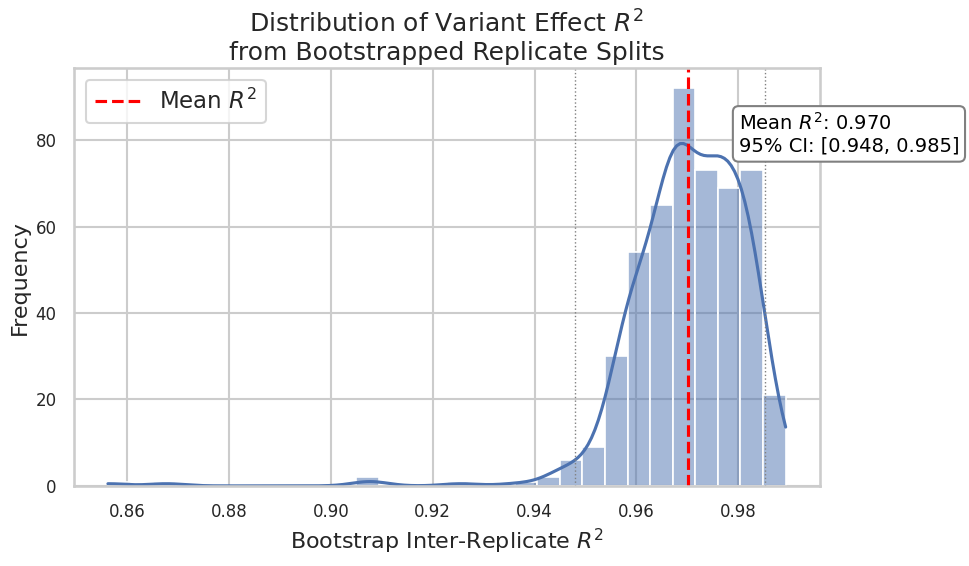

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Seaborn and Matplotlib style for presentation
sns.set(style="whitegrid", context="talk", palette="muted")

# Calculate statistics
mean_r2 = np.mean(r_list)
ci_lower, ci_upper = np.percentile(r_list, [2.5, 97.5])

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.histplot(r_list, bins=30, kde=True, color="#4C72B0", edgecolor='white', linewidth=1.2)

# Labels and title
plt.xlabel("Bootstrap Inter-Replicate $R^2$", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Distribution of Variant Effect $R^2$\nfrom Bootstrapped Replicate Splits", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Annotate mean and 95% CI on the plot
annotation_text = f"Mean $R^2$: {mean_r2:.3f}\n95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]"
plt.axvline(mean_r2, color='red', linestyle='--', label='Mean $R^2$')
plt.text(mean_r2 + 0.01, plt.ylim()[1]*0.8, annotation_text,
         color='black', fontsize=14, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# Optional: vertical lines for CI
plt.axvline(ci_lower, color='gray', linestyle=':', linewidth=1)
plt.axvline(ci_upper, color='gray', linestyle=':', linewidth=1)

plt.legend()
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/GTeX_experiment/iq.svg",format="svg")
plt.show()
